# Problem A: Feature Engineering and Feature Selection

Read the authoritative order-level cohort, labels and maturity-safe split exported by `02_preprocessing_problemA.ipynb`. Engineer purchase-time histories, rank features using validation late-class Average Precision, and export the selected prefix for classification. Requires scikit-learn 1.6.1; no imputation, encoding or scaling is learned from validation or Test for the downstream models.

## 1. Setup and Load Preprocessed Data

The input artifacts are `promise_band_base.csv` and `order_seller_bridge.csv`. Cohort inclusion, labels and split assignments are inherited from 02 without recomputation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents]
            if (candidate / "notebooks" / "02_preprocessing_problemA.ipynb").exists())
OUT = ROOT / "data" / "processed"
BANDS = ["under_half", "half_to_full", "late"]
BAND_TO_CODE = {band: i for i, band in enumerate(BANDS)}
CAT_COLS = ["customer_state", "seller_state", "product_category", "purchase_dow", "purchase_month"]
CORR_THRESHOLD = 0.92
MI_SAMPLE = 15000
RANDOM_STATE = 42
base = pd.read_csv(OUT / "promise_band_base.csv",
                   parse_dates=["order_purchase_timestamp", "order_delivered_customer_date"])
seller_pairs = pd.read_csv(OUT / "order_seller_bridge.csv")
assert base["order_id"].is_unique
assert len(base) == 96470
assert base["split"].value_counts().to_dict() == {
    "train": 64429, "val": 12541, "test": 14471, "excluded": 5029}
assert set(base["promise_band"]) == set(BANDS)
assert not seller_pairs.duplicated(["order_id", "seller_id"]).any()
assert set(seller_pairs["order_id"]) == set(base["order_id"])
t_val = base.loc[base["split"].eq("val"), "order_purchase_timestamp"].min()
t_test = base.loc[base["split"].eq("test"), "order_purchase_timestamp"].min()
assert base.loc[base["split"].eq("train"), "order_delivered_customer_date"].lt(t_val).all()
assert base.loc[base["split"].eq("val"), "order_delivered_customer_date"].lt(t_test).all()
print("Preprocessed base:", base.shape)
print("Order-seller bridge:", seller_pairs.shape)
print(base["split"].value_counts().to_string())


Preprocessed base: (96470, 51)
Order-seller bridge: (97811, 2)
split
train       64429
test        14471
val         12541
excluded     5029


## 2. Feature Engineering

### 2.1 Order-level Features

Use the basket, quote, payment, calendar and location fields already aggregated by 02. Missing observations retain their existing semantics.

In [2]:
df = base.copy()
print("Purchase-time order fields loaded from 02; no raw-data reads.")

Purchase-time order fields loaded from 02; no raw-data reads.


### 2.2 Seller and Customer Purchase Histories

Earlier-purchase counts retain their original definitions. Outcome histories use deliveries strictly before the current purchase. Seller history includes every seller participating in each historical order. Empty 30-day windows have count 0 and late rate NaN.

In [3]:
def prior_count_in_window(frame, key, time_col, window_days, out_col):
    work = frame[[key, time_col]].copy()
    work["_i"] = np.arange(len(frame))
    work = work.sort_values([key, time_col, "_i"])
    counts = np.zeros(len(frame), dtype=np.int32)
    delta = np.timedelta64(int(window_days), "D")
    for _, group in work.groupby(key, sort=False):
        times = group[time_col].to_numpy()
        left = np.searchsorted(times, times - delta, side="left")
        right = np.searchsorted(times, times, side="left")
        counts[group["_i"].to_numpy()] = right - left
    frame[out_col] = counts
    return frame


def outcome_history_table(events, key):
    """Cumulative outcomes in delivery-time order, within each key."""
    events = events.dropna(subset=["order_delivered_customer_date", key]).copy()
    events = events.sort_values(["order_delivered_customer_date", "order_id", key])
    grouped = events.groupby(key, sort=False)
    events["n"] = grouped.cumcount() + 1
    events["n_late"] = grouped["is_late"].cumsum()
    events["n_under"] = grouped["is_under_half"].cumsum()
    events["sum_ratio"] = grouped["duration_ratio"].cumsum()
    events["sum_actual"] = grouped["actual_days"].cumsum()
    events["late_rate"] = events["n_late"] / events["n"]
    events["under_half_rate"] = events["n_under"] / events["n"]
    events["mean_ratio"] = events["sum_ratio"] / events["n"]
    events["mean_actual_days"] = events["sum_actual"] / events["n"]
    keep = [
        key,
        "order_delivered_customer_date",
        "n",
        "late_rate",
        "under_half_rate",
        "mean_ratio",
        "mean_actual_days",
    ]
    return events[keep].rename(columns={"order_delivered_customer_date": "known_at"})


def asof_outcomes(left, history, key, prefix):
    renamed = history.rename(columns={
        "n": f"{prefix}_prior_delivered",
        "late_rate": f"{prefix}_prior_late_rate",
        "under_half_rate": f"{prefix}_prior_under_half_rate",
        "mean_ratio": f"{prefix}_prior_mean_ratio",
        "mean_actual_days": f"{prefix}_prior_mean_actual_days",
    })
    left_sorted = left.sort_values(["order_purchase_timestamp", "order_id"])
    right_sorted = renamed.sort_values(["known_at", key])
    merged = pd.merge_asof(
        left_sorted,
        right_sorted,
        left_on="order_purchase_timestamp",
        right_on="known_at",
        by=key,
        direction="backward",
        allow_exact_matches=False,
    )
    merged[f"{prefix}_prior_delivered"] = merged[f"{prefix}_prior_delivered"].fillna(0)
    return merged.drop(columns=["known_at"])


def seller_completed_30d(frame, events):
    """Primary-seller deliveries in [purchase - 30 days, purchase)."""
    counts = np.zeros(len(frame), dtype=np.int32)
    rates = np.full(len(frame), np.nan)
    queries = frame[["seller_id", "order_purchase_timestamp"]].copy()
    queries["_position"] = np.arange(len(frame))
    histories = {seller: group.sort_values(["order_delivered_customer_date", "order_id"])
                 for seller, group in events.groupby("seller_id", sort=False)}
    for seller, group in queries.groupby("seller_id", sort=False):
        history = histories.get(seller)
        if history is None:
            continue
        delivered = history["order_delivered_customer_date"].to_numpy()
        purchase = group["order_purchase_timestamp"].to_numpy()
        left = np.searchsorted(delivered, purchase - np.timedelta64(30, "D"), side="left")
        right = np.searchsorted(delivered, purchase, side="left")
        number = right - left
        cumulative_late = np.r_[0, history["is_late"].to_numpy().cumsum()]
        late_number = cumulative_late[right] - cumulative_late[left]
        positions = group["_position"].to_numpy()
        counts[positions] = number
        rates[positions] = np.divide(late_number, number, out=np.full(len(number), np.nan), where=number > 0)
    frame["seller_delivered_30d"] = counts
    frame["seller_prior_late_rate_30d"] = rates
    return frame


label_cols = [
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "is_late",
    "is_under_half",
    "duration_ratio",
    "actual_days",
]
order_events = df[label_cols + ["seller_id", "customer_unique_id", "product_category", "route"]]

df = df.sort_values(["seller_id", "order_purchase_timestamp", "order_id"])
df["seller_prior_orders"] = df.groupby("seller_id").cumcount().astype(np.int32)
df["seller_days_since_prev"] = (
    df["order_purchase_timestamp"] - df.groupby("seller_id")["order_purchase_timestamp"].shift(1)
).dt.total_seconds() / 86400
df = prior_count_in_window(df, "seller_id", "order_purchase_timestamp", 30, "seller_orders_30d")

df = df.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
df["customer_prior_orders"] = df.groupby("customer_unique_id").cumcount().astype(np.int32)
df["customer_days_since_prev"] = (
    df["order_purchase_timestamp"]
    - df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1)
).dt.total_seconds() / 86400

seller_events = order_events.drop(columns=["seller_id"]).merge(seller_pairs, on="order_id", how="inner")
df = seller_completed_30d(df, seller_events)
seller_history = outcome_history_table(seller_events, "seller_id")
df = asof_outcomes(df, seller_history, "seller_id", "seller")

pair_left = seller_pairs.merge(
    df[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="inner",
)
pair_scored = asof_outcomes(pair_left, seller_history, "seller_id", "seller")
sellers_max = pair_scored.groupby("order_id")["seller_prior_late_rate"].max()
df["sellers_max_prior_late_rate"] = df["order_id"].map(sellers_max)



### 2.3 Customer Outcome History

Completed customer deliveries only; missing rates remain missing when no outcome is known.

In [4]:
df = asof_outcomes(df, outcome_history_table(order_events, "customer_unique_id"), "customer_unique_id", "customer")

### 2.4 Category Historical Features

Category outcomes are joined in delivery-time order, excluding exact purchase-time matches.

In [5]:
df = asof_outcomes(df, outcome_history_table(order_events, "product_category"), "product_category", "category")

### 2.5 Route Historical Features

Keep the existing seller-state to customer-state route definition and completed-delivery outcome history.

In [6]:
df = asof_outcomes(df, outcome_history_table(order_events, "route"), "route", "route")
print("seller history missing: {:.1f}%".format(100 * df["seller_prior_delivered"].eq(0).mean()))
print("customer history missing: {:.1f}%".format(100 * df["customer_prior_delivered"].eq(0).mean()))
print("category history missing: {:.1f}%".format(100 * df["category_prior_delivered"].eq(0).mean()))
print("route history missing: {:.1f}%".format(100 * df["route_prior_delivered"].eq(0).mean()))


seller history missing: 5.4%
customer history missing: 97.9%
category history missing: 0.4%
route history missing: 0.8%


### 2.6 Market Historical Features

Marketplace cumulative and 30-day outcomes include only deliveries completed before purchase.

In [7]:
# Marketplace mix among deliveries already completed before this purchase.
market = (
    df[["order_delivered_customer_date", "is_late", "is_under_half", "duration_ratio"]]
    .dropna(subset=["order_delivered_customer_date"])
    .sort_values("order_delivered_customer_date")
)
times = market["order_delivered_customer_date"].to_numpy()
c_n = np.arange(1, len(market) + 1, dtype=float)
c_late = market["is_late"].to_numpy().cumsum()
c_under = market["is_under_half"].to_numpy().cumsum()
c_ratio = market["duration_ratio"].to_numpy().cumsum()
purchase = df["order_purchase_timestamp"].to_numpy()
idx = np.searchsorted(times, purchase, side="left") - 1
idx30 = np.searchsorted(times, purchase - np.timedelta64(30, "D"), side="left") - 1
idx_safe = np.clip(idx, 0, None)
idx30_safe = np.clip(idx30, 0, None)
has_past = idx >= 0
n30 = np.where(has_past, idx - idx30, 0).astype(float)


def _window_sum(cumulative):
    total = np.where(has_past, cumulative[idx_safe], np.nan)
    before = np.where(idx30 >= 0, cumulative[idx30_safe], 0.0)
    return total - before


df["market_prior_late_rate"] = np.where(has_past, c_late[idx_safe] / c_n[idx_safe], np.nan)
df["market_prior_under_half_rate"] = np.where(has_past, c_under[idx_safe] / c_n[idx_safe], np.nan)
df["market_prior_mean_ratio"] = np.where(has_past, c_ratio[idx_safe] / c_n[idx_safe], np.nan)
df["market_30d_n"] = n30
df["market_30d_late_rate"] = np.where(n30 > 0, _window_sum(c_late) / n30, np.nan)
df["market_30d_under_half_rate"] = np.where(n30 > 0, _window_sum(c_under) / n30, np.nan)
df["market_30d_mean_ratio"] = np.where(n30 > 0, _window_sum(c_ratio) / n30, np.nan)
print(df[["market_prior_late_rate", "market_30d_late_rate", "market_30d_n"]].describe().round(3))


       market_prior_late_rate  market_30d_late_rate  market_30d_n
count               96204.000             96204.000     96470.000
mean                    0.056                 0.075      5291.726
std                     0.022                 0.054      1855.820
min                     0.002                 0.000         0.000
25%                     0.039                 0.037      4013.000
50%                     0.059                 0.056      5879.000
75%                     0.079                 0.101      6678.000
max                     0.085                 0.500      8310.000


### History Leakage Checks

Check the existing single-seller example and valid rate bounds. Labels and delivery timestamps are used to construct histories and audit maturity; they are excluded from candidate model inputs.

In [8]:
# Single-seller orders only: seller history then matches the primary-seller timeline.
single = df.loc[df["n_sellers"].eq(1)].sort_values(["seller_id", "order_purchase_timestamp", "order_id"])
first = single.groupby("seller_id", sort=False).nth(0).reset_index()
second = single.groupby("seller_id", sort=False).nth(1).reset_index()
both = first[["seller_id", "is_late", "order_delivered_customer_date"]].merge(
    second[["seller_id", "seller_prior_delivered", "seller_prior_late_rate", "order_purchase_timestamp"]],
    on="seller_id",
)
checked = both.loc[
    both["order_delivered_customer_date"].lt(both["order_purchase_timestamp"])
    & both["seller_prior_delivered"].eq(1)
].head(8)
audit = checked[["seller_prior_delivered", "seller_prior_late_rate", "is_late"]].rename(
    columns={"is_late": "first_order_was_late"}
)
print("Second single-seller order, with exactly one delivery already known:")
print(audit.round(3).to_string(index=False))
assert len(audit) >= 5
assert np.allclose(audit["seller_prior_late_rate"].to_numpy(), audit["first_order_was_late"].to_numpy())

for col in [
    "seller_prior_late_rate",
    "customer_prior_late_rate",
    "category_prior_under_half_rate",
    "route_prior_late_rate",
    "market_30d_late_rate",
]:
    values = df[col].dropna()
    assert values.between(0, 1).all(), col

# A seller's own delivery cannot be known at that seller's purchase time.
own = df["seller_prior_delivered"].eq(0) | df["order_delivered_customer_date"].gt(df["order_purchase_timestamp"])
assert own.all()
print("audit passed")


Second single-seller order, with exactly one delivery already known:
 seller_prior_delivered  seller_prior_late_rate  first_order_was_late
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
audit passed


## 3. Candidate Feature Table

Build the 74-feature table and ordered dictionary in memory. Preserve the authoritative split and nine metadata, label and diagnostic columns.

In [9]:
FEATURE_SPEC = [
    ("n_items", "basket", "Item rows on the order"),
    ("n_sellers", "basket", "Distinct sellers on the order"),
    ("n_products", "basket", "Distinct products on the order"),
    ("n_categories", "basket", "Distinct categories on the order"),
    ("price_sum", "basket", "Sum of item prices"),
    ("price_mean", "basket", "Mean item price"),
    ("price_max", "basket", "Highest item price"),
    ("freight_sum", "basket", "Sum of quoted freight"),
    ("freight_mean", "basket", "Mean quoted freight"),
    ("freight_to_price", "basket", "Freight divided by price"),
    ("weight_g_sum", "basket", "Total catalog weight in grams"),
    ("weight_g_max", "basket", "Heaviest item in grams"),
    ("volume_cm3_sum", "basket", "Total catalog volume in cm^3"),
    ("volume_cm3_max", "basket", "Largest item volume in cm^3"),
    ("photos_max", "basket", "Most photos on any item listing"),
    ("name_len_mean", "basket", "Mean product-name length"),
    ("desc_len_mean", "basket", "Mean product-description length"),
    ("product_category", "basket", "Category of the highest-priced item"),
    ("customer_state", "route", "Customer state"),
    ("seller_state", "route", "State of the highest-priced item's seller"),
    ("same_state", "route", "Customer and primary seller are in the same state"),
    ("distance_km", "route", "Great-circle distance between zip-code centroids"),
    ("distance_missing", "route", "Either zip code has no usable centroid"),
    ("customer_lat", "route", "Customer zip-code centroid latitude"),
    ("customer_lng", "route", "Customer zip-code centroid longitude"),
    ("seller_lat", "route", "Primary seller zip-code centroid latitude"),
    ("seller_lng", "route", "Primary seller zip-code centroid longitude"),
    ("purchase_hour", "calendar", "Hour of purchase"),
    ("purchase_dow", "calendar", "Day of week, Monday is 0"),
    ("purchase_month", "calendar", "Month of purchase"),
    ("is_weekend", "calendar", "Purchase on Saturday or Sunday"),
    ("n_payments", "payment", "Number of payment rows"),
    ("installments_max", "payment", "Maximum installments"),
    ("payment_value_sum", "payment", "Sum of payment values"),
    ("pay_credit_card", "payment", "Share of payment value on credit card"),
    ("pay_boleto", "payment", "Share of payment value on boleto"),
    ("pay_voucher", "payment", "Share of payment value on voucher"),
    ("pay_debit_card", "payment", "Share of payment value on debit card"),
    ("promised_days", "quote", "Length of the promised window in days"),
    ("seller_prior_orders", "seller_history", "Earlier purchases of the primary seller"),
    ("seller_orders_30d", "seller_history", "Primary seller purchases in the previous 30 days"),
    ("seller_delivered_30d", "seller_history", "Primary seller deliveries completed in the previous 30 days"),
    ("seller_prior_late_rate_30d", "seller_history", "Late share among those 30-day deliveries"),
    ("seller_days_since_prev", "seller_history", "Days since the primary seller's previous purchase"),
    ("seller_prior_delivered", "seller_history", "Primary seller deliveries already completed"),
    ("seller_prior_late_rate", "seller_history", "Late share among those completed deliveries"),
    ("seller_prior_under_half_rate", "seller_history", "Under-half share among those completed deliveries"),
    ("seller_prior_mean_ratio", "seller_history", "Mean actual/promised ratio among those deliveries"),
    ("seller_prior_mean_actual_days", "seller_history", "Mean actual delivery days among those deliveries"),
    ("sellers_max_prior_late_rate", "seller_history", "Highest prior late rate among sellers on this order"),
    ("customer_prior_orders", "customer_history", "Earlier purchases of this customer"),
    ("customer_days_since_prev", "customer_history", "Days since this customer's previous purchase"),
    ("customer_prior_delivered", "customer_history", "This customer's deliveries already completed"),
    ("customer_prior_late_rate", "customer_history", "Late share among those completed deliveries"),
    ("customer_prior_under_half_rate", "customer_history", "Under-half share among those completed deliveries"),
    ("customer_prior_mean_ratio", "customer_history", "Mean actual/promised ratio among those deliveries"),
    ("customer_prior_mean_actual_days", "customer_history", "Mean actual delivery days among those deliveries"),
    ("category_prior_delivered", "category_history", "Completed deliveries in this category"),
    ("category_prior_late_rate", "category_history", "Late share in this category before this purchase"),
    ("category_prior_under_half_rate", "category_history", "Under-half share in this category before this purchase"),
    ("category_prior_mean_ratio", "category_history", "Mean actual/promised ratio in this category"),
    ("category_prior_mean_actual_days", "category_history", "Mean actual days in this category"),
    ("route_prior_delivered", "route_history", "Completed deliveries on this seller-state to customer-state route"),
    ("route_prior_late_rate", "route_history", "Late share on this route before this purchase"),
    ("route_prior_under_half_rate", "route_history", "Under-half share on this route before this purchase"),
    ("route_prior_mean_ratio", "route_history", "Mean actual/promised ratio on this route"),
    ("route_prior_mean_actual_days", "route_history", "Mean actual days on this route"),
    ("market_prior_late_rate", "market_history", "Late share of all deliveries completed before this purchase"),
    ("market_prior_under_half_rate", "market_history", "Under-half share of all deliveries completed before this purchase"),
    ("market_prior_mean_ratio", "market_history", "Mean actual/promised ratio of those deliveries"),
    ("market_30d_n", "market_history", "Deliveries completed in the 30 days before this purchase"),
    ("market_30d_late_rate", "market_history", "Late share over that 30-day window"),
    ("market_30d_under_half_rate", "market_history", "Under-half share over that 30-day window"),
    ("market_30d_mean_ratio", "market_history", "Mean actual/promised ratio over that 30-day window"),
]

feature_names = [name for name, _, _ in FEATURE_SPEC]
missing = [name for name in feature_names if name not in df.columns]
assert not missing, missing

dictionary = pd.DataFrame(FEATURE_SPEC, columns=["feature", "group", "description"])
dictionary["role"] = "feature"
diagnostics = pd.DataFrame([
    ("order_id", "id", "Order identifier", "id"),
    ("customer_unique_id", "id", "Customer identifier across orders", "id"),
    ("seller_id", "id", "Primary seller identifier", "id"),
    ("order_purchase_timestamp", "meta", "Decision time, used only to build the split", "meta"),
    ("order_delivered_customer_date", "meta", "Label time. Not a feature. Used to drop in-flight training labels.", "meta"),
    ("split", "meta", "train, val, test, or excluded when the label was not yet known", "meta"),
    ("promise_band", "label", "under_half, half_to_full, or late", "label"),
    ("actual_days", "diagnostic", "Actual days from purchase to delivery. Not a feature.", "diagnostic"),
    ("duration_ratio", "diagnostic", "Actual time divided by promised time. Not a feature.", "diagnostic"),
], columns=["feature", "group", "description", "role"])
dictionary = pd.concat([diagnostics, dictionary], ignore_index=True)

forbidden = {
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "order_approved_at",
    "order_status",
    "shipping_limit_date",
    "review_score",
    "actual_hours",
    "actual_days",
    "duration_ratio",
    "is_late",
    "is_under_half",
    "promise_band",
}
assert forbidden.isdisjoint(feature_names)

meta_cols = [
    "order_id",
    "customer_unique_id",
    "seller_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "split",
    "promise_band",
    "actual_days",
    "duration_ratio",
]
model_df = df[meta_cols + feature_names].sort_values(["order_purchase_timestamp", "order_id"])
# Formal schema and label-maturity handoff checks.
assert len(feature_names) == 74
assert len(feature_names) == len(set(feature_names))
assert model_df.shape == (96470, 83), model_df.shape
assert model_df["order_id"].is_unique
assert model_df["split"].value_counts().to_dict() == {
    "train": 64429, "val": 12541, "test": 14471, "excluded": 5029}
assert set(model_df["promise_band"]) == set(BANDS)
train_part = model_df.loc[model_df["split"].eq("train")]
val_part = model_df.loc[model_df["split"].eq("val")]
test_part = model_df.loc[model_df["split"].eq("test")]
assert train_part["order_delivered_customer_date"].lt(t_val).all()
assert val_part["order_delivered_customer_date"].lt(t_test).all()
assert train_part["order_purchase_timestamp"].max() < val_part["order_purchase_timestamp"].min()
assert val_part["order_purchase_timestamp"].max() < test_part["order_purchase_timestamp"].min()
assert dictionary.loc[dictionary["role"].eq("feature"), "feature"].tolist() == feature_names
assert model_df.columns.tolist() == meta_cols + feature_names
assert forbidden.isdisjoint(feature_names)
print("Handoff assertions passed; label-mature split:")
print(model_df["split"].value_counts().to_string())


print("Candidate table:", model_df.shape)
print("Candidate features:", len(feature_names))
table = model_df.copy()
table["y"] = table["promise_band"].map(BAND_TO_CODE).astype(int)
train = table.loc[table["split"].eq("train")].copy()
val = table.loc[table["split"].eq("val")].copy()
test = table.loc[table["split"].eq("test")].copy()


Handoff assertions passed; label-mature split:
split
train       64429
test        14471
val         12541
excluded     5029
Candidate table: (96470, 83)
Candidate features: 74


## 4. Feature Screening

### 4.1 Missingness / Mechanical Filtering

Train-only missingness above 95% and constant features are removed.

In [10]:
profile = pd.DataFrame({
    "feature": feature_names,
    "train_missing": [train[col].isna().mean() for col in feature_names],
    "train_nunique": [train[col].nunique(dropna=True) for col in feature_names],
})
profile = profile.merge(dictionary[["feature", "group", "description"]], on="feature", how="left")
dropped_mechanical = profile.loc[
    profile["train_missing"].gt(0.95) | profile["train_nunique"].le(1),
    "feature",
].tolist()
surviving = [col for col in feature_names if col not in dropped_mechanical]
print("dropped for missingness or zero variance:")
print(dropped_mechanical or "(none)")
print()
print("highest train missing rates:")
print(
    profile.sort_values("train_missing", ascending=False)
    .head(12)[["feature", "group", "train_missing", "train_nunique"]]
    .to_string(index=False)
)


dropped for missingness or zero variance:
['customer_days_since_prev', 'customer_prior_late_rate', 'customer_prior_under_half_rate', 'customer_prior_mean_ratio', 'customer_prior_mean_actual_days']

highest train missing rates:
                        feature            group  train_missing  train_nunique
       customer_prior_late_rate customer_history       0.982710              6
customer_prior_mean_actual_days customer_history       0.982710           1071
      customer_prior_mean_ratio customer_history       0.982710           1071
 customer_prior_under_half_rate customer_history       0.982710              7
       customer_days_since_prev customer_history       0.968399           1388
     seller_prior_late_rate_30d   seller_history       0.101662           1543
  seller_prior_mean_actual_days   seller_history       0.059430          28302
        seller_prior_mean_ratio   seller_history       0.059430          28307
   seller_prior_under_half_rate   seller_history       0.05943

### 4.2 Mutual Information

Train-sample MI with the binary late indicator is a correlation tie-break, while the formal target remains three-class promise band. Convert only non-missing categories to strings before mapping; retain NaN before the existing MI imputation.

                        feature  mutual_info            group
   route_prior_mean_actual_days       0.0215    route_history
    route_prior_under_half_rate       0.0211    route_history
        market_prior_mean_ratio       0.0185   market_history
         route_prior_mean_ratio       0.0185    route_history
   market_prior_under_half_rate       0.0183   market_history
         market_prior_late_rate       0.0155   market_history
                   customer_lat       0.0152            route
          route_prior_late_rate       0.0151    route_history
          route_prior_delivered       0.0144    route_history
     market_30d_under_half_rate       0.0131   market_history
                   market_30d_n       0.0120   market_history
           market_30d_late_rate       0.0118   market_history
                     seller_lat       0.0114            route
          market_30d_mean_ratio       0.0112   market_history
                   customer_lng       0.0107            route
      ca

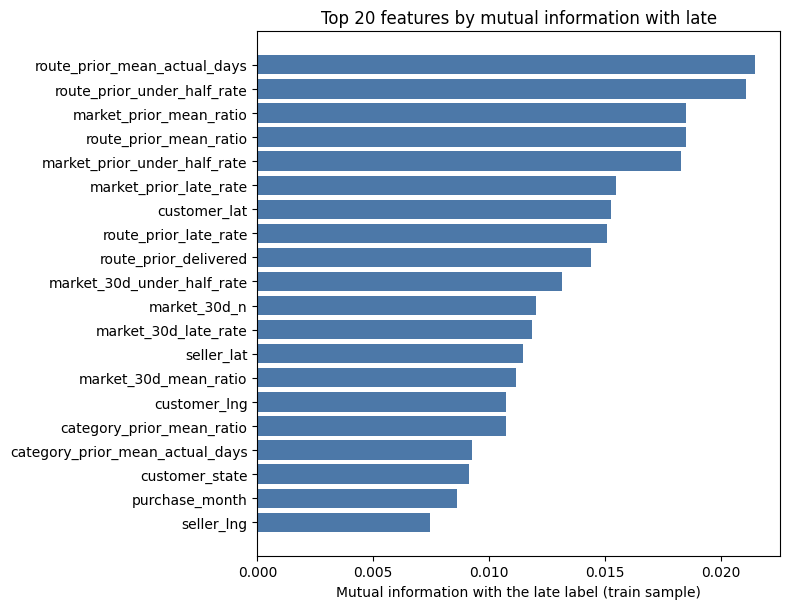

In [11]:
cat_cols = [col for col in surviving if col in CAT_COLS]
num_cols = [col for col in surviving if col not in cat_cols]


def encoded_frame(frame, cat_maps):
    encoded = pd.DataFrame(index=frame.index)
    for col in num_cols:
        encoded[col] = pd.to_numeric(frame[col], errors="coerce")
    for col in cat_cols:
        mask = frame[col].notna()
        encoded[col] = np.nan
        encoded.loc[mask, col] = frame.loc[mask, col].astype(str).map(cat_maps[col])
    return encoded


cat_maps = {}
for col in cat_cols:
    levels = pd.Index(train[col].dropna().astype(str).unique())
    cat_maps[col] = {level: i for i, level in enumerate(levels)}

train_encoded = encoded_frame(train, cat_maps)
y_train = train["y"].to_numpy()
sample_idx, _ = train_test_split(
    np.arange(len(train_encoded)),
    train_size=min(MI_SAMPLE, len(train_encoded)),
    stratify=y_train,
    random_state=RANDOM_STATE,
)
sample = train_encoded.iloc[sample_idx].copy()
y_sample = (y_train[sample_idx] == 2).astype(int)

discrete_idx = []
for col in sample.columns:
    if col in cat_cols:
        sample[col] = sample[col].fillna(sample[col].max() + 1 if sample[col].notna().any() else 0)
        discrete_idx.append(True)
    else:
        sample[col] = sample[col].fillna(sample[col].median())
        discrete_idx.append(False)

continuous = [col for col, is_discrete in zip(sample.columns, discrete_idx) if not is_discrete]
scaler = StandardScaler()
sample[continuous] = scaler.fit_transform(sample[continuous])

mi_values = mutual_info_classif(
    sample.to_numpy(dtype=float),
    y_sample,
    discrete_features=np.array(discrete_idx),
    n_neighbors=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
mi = pd.Series(mi_values, index=sample.columns, name="mutual_info")
mi_table = mi.sort_values(ascending=False).rename("mutual_info").reset_index().rename(columns={"index": "feature"})
mi_table = mi_table.merge(dictionary[["feature", "group"]], on="feature", how="left")
print(mi_table.head(20).round(4).to_string(index=False))

top = mi_table.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6.2))
ax.barh(top["feature"], top["mutual_info"], color="#4C78A8")
ax.set_xlabel("Mutual information with the late label (train sample)")
ax.set_title("Top 20 features by mutual information with late")
fig.tight_layout()
plt.show()


### 4.3 Correlation Filtering

Train-only numeric Spearman correlation at or above 0.92 keeps the feature with higher MI.

In [12]:
corr = train[num_cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman").abs()
ordered = sorted(num_cols, key=lambda col: mi.get(col, 0.0), reverse=True)
kept_num = []
dropped_pairs = []
for col in ordered:
    if not kept_num:
        kept_num.append(col)
        continue
    correlations = corr.loc[col, kept_num]
    partner = correlations.idxmax()
    rho = float(correlations.max())
    if np.isnan(rho) or rho < CORR_THRESHOLD:
        kept_num.append(col)
    else:
        dropped_pairs.append({
            "dropped": col,
            "kept_instead": partner,
            "abs_spearman": round(rho, 3),
            "mi_dropped": round(float(mi.get(col, 0.0)), 4),
            "mi_kept": round(float(mi.get(partner, 0.0)), 4),
        })

pair_table = pd.DataFrame(dropped_pairs)
print(f"numeric columns kept: {len(kept_num)} of {len(num_cols)}")
print(f"categorical columns kept through this step: {len(cat_cols)}")
if pair_table.empty:
    print("no pairs above the threshold")
else:
    print(pair_table.sort_values("abs_spearman", ascending=False).to_string(index=False))

model_features = cat_cols + kept_num
print("columns entering the tree:", len(model_features))


numeric columns kept: 50 of 64
categorical columns kept through this step: 5
                       dropped                kept_instead  abs_spearman  mi_dropped  mi_kept
                     price_max                  price_mean         0.999      0.0027   0.0041
  market_prior_under_half_rate     market_prior_mean_ratio         0.995      0.0183   0.0185
   sellers_max_prior_late_rate      seller_prior_late_rate         0.995      0.0022   0.0026
        seller_prior_delivered         seller_prior_orders         0.992      0.0000   0.0013
                  weight_g_max                weight_g_sum         0.983      0.0016   0.0036
                volume_cm3_sum              volume_cm3_max         0.982      0.0034   0.0052
        route_prior_mean_ratio route_prior_under_half_rate         0.966      0.0185   0.0211
category_prior_under_half_rate   category_prior_mean_ratio         0.963      0.0047   0.0107
                     price_sum                  price_mean         0.954     

## 5. Permutation Importance

Fit the original balanced three-class HGB on Train. Rank features by the drop in validation late Average Precision under five permutation repeats. Validation determines the ranking; Test does not.

In [13]:
def design_matrix(frame, features, cat_maps):
    columns = []
    names = []
    for feature in features:
        if feature in cat_maps:
            codes = frame[feature].astype(str).map(cat_maps[feature]).to_numpy(dtype=float)
            columns.append(codes.reshape(-1, 1))
        else:
            columns.append(pd.to_numeric(frame[feature], errors="coerce").to_numpy(dtype=float).reshape(-1, 1))
        names.append(feature)
    matrix = np.hstack(columns)
    categorical = np.array([feature in cat_maps for feature in names])
    return matrix, names, categorical


def fit_model(features):
    maps = {}
    for feature in features:
        if feature in CAT_COLS:
            levels = pd.Index(train[feature].dropna().astype(str).unique())
            maps[feature] = {level: i for i, level in enumerate(levels)}
    x_train, names, categorical = design_matrix(train, features, maps)
    x_val, _, _ = design_matrix(val, features, maps)
    x_test, _, _ = design_matrix(test, features, maps)
    model = HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=0.1,
        class_weight="balanced",
        categorical_features=categorical if categorical.any() else None,
        random_state=RANDOM_STATE,
        early_stopping=False,
    )
    model.fit(x_train, train["y"].to_numpy())
    return model, maps, names, x_train, x_val, x_test


def late_average_precision(estimator, X, y):
    probability = estimator.predict_proba(X)
    late_index = list(estimator.classes_).index(2)
    return average_precision_score(np.asarray(y) == 2, probability[:, late_index])


def score_predictions(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2]),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", labels=[0, 1, 2]),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "quadratic_kappa": cohen_kappa_score(y_true, y_pred, labels=[0, 1, 2], weights="quadratic"),
        "late_f1": f1_score(y_true == 2, y_pred == 2, zero_division=0),
    }


full_model, full_maps, full_names, x_train, x_val, x_test = fit_model(model_features)
perm = permutation_importance(
    full_model,
    x_val,
    val["y"].to_numpy(),
    scoring=late_average_precision,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": full_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})
importance = importance.merge(dictionary[["feature", "group", "description"]], on="feature", how="left")
importance = importance.merge(mi.rename("mutual_info"), left_on="feature", right_index=True, how="left")
importance["stable_core"] = importance["importance_mean"].gt(importance["importance_std"])
importance = importance.sort_values("importance_mean", ascending=False)
print(importance[["feature", "group", "importance_mean", "importance_std", "stable_core"]].round(4).to_string(index=False))
n_core = int(importance["stable_core"].sum())
print()
print(f"stable core: {n_core} of {len(model_features)} tree inputs")


                        feature            group  importance_mean  importance_std  stable_core
                  promised_days            quote           0.0511          0.0019         True
    route_prior_under_half_rate    route_history           0.0301          0.0013         True
                    distance_km            route           0.0105          0.0010         True
   route_prior_mean_actual_days    route_history           0.0084          0.0007         True
                   freight_mean           basket           0.0074          0.0004         True
  seller_prior_mean_actual_days   seller_history           0.0048          0.0006         True
                   customer_lat            route           0.0039          0.0010         True
                 customer_state            route           0.0030          0.0021         True
               product_category           basket           0.0029          0.0029        False
                   customer_lng            route  

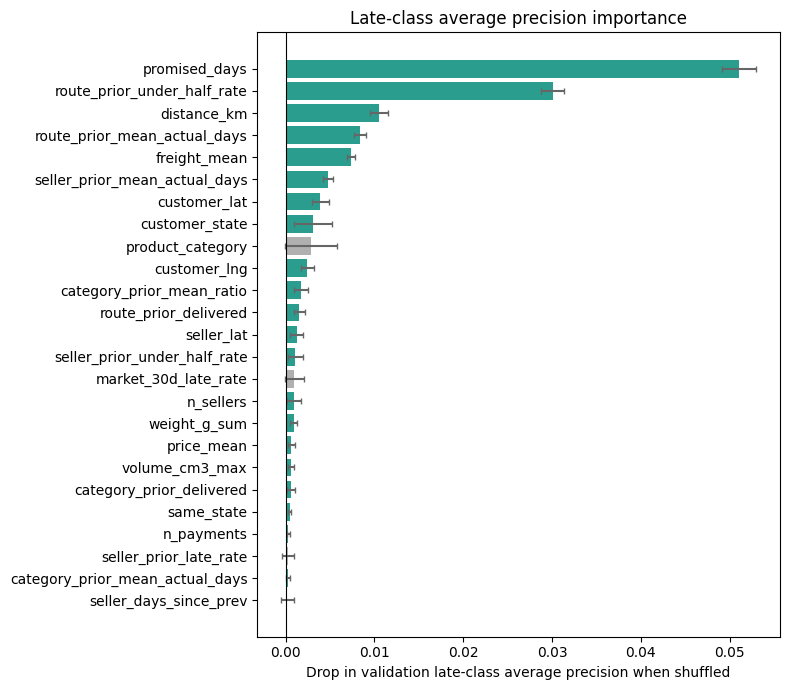

In [14]:
plot_df = importance.head(25).iloc[::-1]
colors = ["#2A9D8F" if flag else "#B0B0B0" for flag in plot_df["stable_core"]]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    color=colors,
    ecolor="#666666",
    capsize=2,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Drop in validation late-class average precision when shuffled")
ax.set_title("Late-class average precision importance")
fig.tight_layout()
plt.show()


## 6. Feature Prefix Evaluation

Evaluate the unchanged 10 / 16 / 24 / 36 / full prefix grid. Retain the shortest prefix within 0.01 of the best validation late AP; no count or selected list is assumed.

            feature_set  n_features split  macro_f1  weighted_f1   mcc  quadratic_kappa  late_f1  late_ap
         majority_class           0 train     0.237        0.393 0.000            0.000    0.000    0.080
         majority_class           0   val     0.276        0.584 0.000            0.000    0.000    0.054
after_mechanical_filter          69 train     0.721        0.758 0.580            0.642    0.652    0.749
after_mechanical_filter          69   val     0.320        0.617 0.117            0.095    0.000    0.124
   top_10_by_importance          10 train     0.646        0.694 0.472            0.546    0.558    0.609
   top_10_by_importance          10   val     0.434        0.616 0.223            0.278    0.189    0.133
   top_16_by_importance          16 train     0.673        0.718 0.513            0.588    0.590    0.650
   top_16_by_importance          16   val     0.414        0.626 0.143            0.232    0.161    0.144
   top_24_by_importance          24 train     


              precision    recall  f1-score   support

  under_half      0.760     0.775     0.767      8847
half_to_full      0.310     0.320     0.315      3019
        late      0.214     0.129     0.161       675

    accuracy                          0.631     12541
   macro avg      0.428     0.408     0.414     12541
weighted avg      0.622     0.631     0.626     12541



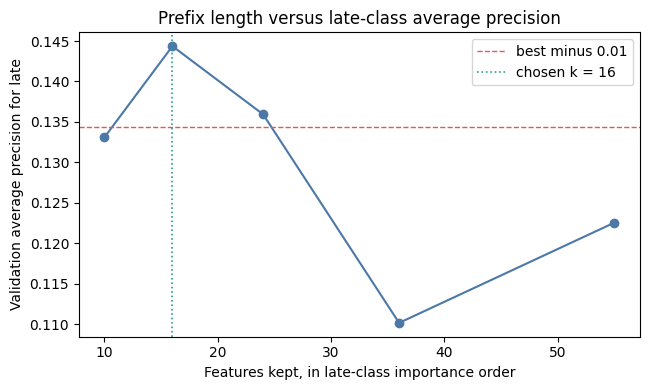

In [15]:
def evaluate_feature_set(name, features, splits):
    model, maps, _, _, _, _ = fit_model(features)
    rows = []
    for split_name, frame in splits:
        matrix, _, _ = design_matrix(frame, features, maps)
        pred = model.predict(matrix)
        probability = model.predict_proba(matrix)
        late_index = list(model.classes_).index(2)
        metrics_row = score_predictions(frame["y"], pred)
        metrics_row["late_ap"] = average_precision_score(frame["y"].eq(2), probability[:, late_index])
        rows.append({
            "feature_set": name,
            "n_features": len(features),
            "split": split_name,
            **metrics_row,
        })
    return rows, model, maps


ranking = (
    importance.sort_values(["importance_mean", "mutual_info"], ascending=[False, False])["feature"]
    .tolist()
)
prefix_sizes = [k for k in (10, 16, 24, 36) if k < len(ranking)]
prefix_sizes.append(len(ranking))

metric_rows = []
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(train), 1)), train["y"])
for split_name, frame in [("train", train), ("val", val)]:
    pred = dummy.predict(np.zeros((len(frame), 1)))
    metric_rows.append({
        "feature_set": "majority_class",
        "n_features": 0,
        "split": split_name,
        **score_predictions(frame["y"], pred),
        "late_ap": float(frame["y"].eq(2).mean()),
    })

mech_rows, _, _ = evaluate_feature_set(
    "after_mechanical_filter", surviving, [("train", train), ("val", val)]
)
metric_rows.extend(mech_rows)

fitted_by_k = {}
for k in prefix_sizes:
    rows, model, maps = evaluate_feature_set(
        f"top_{k}_by_importance", ranking[:k], [("train", train), ("val", val)]
    )
    metric_rows.extend(rows)
    fitted_by_k[k] = (model, maps, ranking[:k])

metrics = pd.DataFrame(metric_rows)
print(metrics.round(3).to_string(index=False))

val_curve = (
    metrics.loc[metrics["split"].eq("val") & metrics["feature_set"].str.startswith("top_")]
    .sort_values("n_features")
)
best_ap = float(val_curve["late_ap"].max())
eligible = val_curve.loc[val_curve["late_ap"] >= best_ap - 0.01]
chosen_k = int(eligible["n_features"].min())
selected_model, selected_maps, selected_features = fitted_by_k[chosen_k]
print()
print(f"best validation late average precision on the grid: {best_ap:.9f}")
print(f"selection threshold: {best_ap - 0.01:.9f}")
print(f"shortest prefix within 0.01: {chosen_k} features")
print(val_curve[["n_features", "late_ap", "macro_f1", "late_f1"]].to_string(index=False, float_format=lambda value: f"{value:.9f}"))

val_pred = selected_model.predict(design_matrix(val, selected_features, selected_maps)[0])
print()
print(classification_report(val["y"], val_pred, target_names=BANDS, digits=3))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(val_curve["n_features"], val_curve["late_ap"], marker="o", color="#4C78A8")
ax.axhline(best_ap - 0.01, color="#E45756", linestyle="--", linewidth=1, label="best minus 0.01")
ax.axvline(chosen_k, color="#2A9D8F", linestyle=":", linewidth=1.2, label=f"chosen k = {chosen_k}")
ax.set_xlabel("Features kept, in late-class importance order")
ax.set_ylabel("Validation average precision for late")
ax.set_title("Prefix length versus late-class average precision")
ax.legend()
fig.tight_layout()
plt.show()


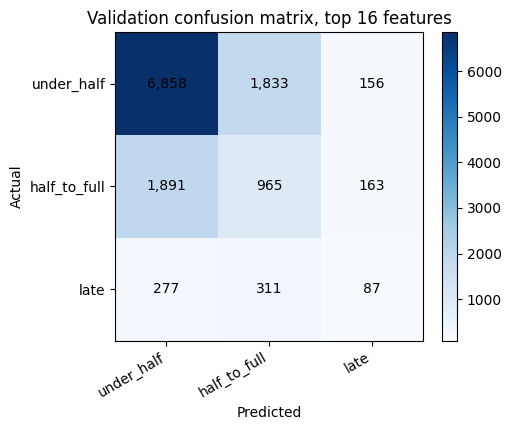

In [16]:
matrix = confusion_matrix(val["y"], val_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
image = ax.imshow(matrix, cmap="Blues")
ax.set_xticks([0, 1, 2], BANDS, rotation=30, ha="right")
ax.set_yticks([0, 1, 2], BANDS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Validation confusion matrix, top {len(selected_features)} features")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## 7. Final Selected Features

The prefix is frozen using Validation. The existing one-off Test diagnostic below cannot change the selected features, ranking or selection rule.

In [17]:
test_matrix = design_matrix(test, selected_features, selected_maps)[0]
test_pred = selected_model.predict(test_matrix)
test_probability = selected_model.predict_proba(test_matrix)
late_index = list(selected_model.classes_).index(2)
test_scores = score_predictions(test["y"], test_pred)
test_scores["late_ap"] = average_precision_score(test["y"].eq(2), test_probability[:, late_index])
test_row = pd.DataFrame([{
    "feature_set": f"top_{len(selected_features)}_by_importance",
    "n_features": len(selected_features),
    "split": "test",
    **test_scores,
}])
print(test_row.round(3).to_string(index=False))
print()
print(classification_report(test["y"], test_pred, target_names=BANDS, digits=3))
test_mix = test["promise_band"].value_counts(normalize=True).reindex(BANDS)
print("test class share (%):")
print((test_mix * 100).round(1).to_string())

final = importance.set_index("feature").loc[selected_features].reset_index()
final.insert(0, "rank", range(1, len(final) + 1))
print()
print("modelling features, in importance order:")
print(final[["rank", "feature", "group", "importance_mean", "stable_core"]].round(4).to_string(index=False))


         feature_set  n_features split  macro_f1  weighted_f1  mcc  quadratic_kappa  late_f1  late_ap
top_16_by_importance          16  test     0.344        0.467 0.07            0.041    0.076    0.057

              precision    recall  f1-score   support

  under_half      0.660     0.446     0.532      8789
half_to_full      0.372     0.496     0.425      4725
        late      0.054     0.127     0.076       957

    accuracy                          0.441     14471
   macro avg      0.362     0.356     0.344     14471
weighted avg      0.526     0.441     0.467     14471

test class share (%):
promise_band
under_half      60.7
half_to_full    32.7
late             6.6

modelling features, in importance order:
 rank                       feature            group  importance_mean  stable_core
    1                 promised_days            quote           0.0511         True
    2   route_prior_under_half_rate    route_history           0.0301         True
    3                   d

## 8. Export for Classification

Write formal artifacts once, after feature engineering and selection have completed in memory. `04_classification_late_delivery.ipynb` reads these artifacts from `data/processed`. The delivery timestamp and label diagnostics never enter candidate features.

In [18]:
assert selected_features == ranking[:chosen_k]
assert len(selected_features) == len(set(selected_features))
assert chosen_k == int(eligible["n_features"].min())
artifacts = {
    "promise_band_feature_table": model_df,
    "promise_band_feature_dictionary": dictionary,
    "selected_features": final,
    "feature_permutation_importance": importance,
    "feature_selection_val_metrics": metrics,
    "feature_train_profile": profile,
    "feature_mutual_info": mi_table,
}
if not pair_table.empty:
    artifacts["feature_dropped_correlated_pairs"] = pair_table
for name, frame in artifacts.items():
    path = OUT / f"{name}.csv"
    frame.to_csv(path, index=False)
    assert path.exists(), path
    print("Exported:", path.resolve())
assert pd.read_csv(OUT / "selected_features.csv")["feature"].tolist() == selected_features
print("Selected features:", len(selected_features))
print(selected_features)


Exported: E:\nus\s3\IT5006\Github\data\processed\promise_band_feature_table.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\promise_band_feature_dictionary.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\selected_features.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\feature_permutation_importance.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\feature_selection_val_metrics.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\feature_train_profile.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\feature_mutual_info.csv
Exported: E:\nus\s3\IT5006\Github\data\processed\feature_dropped_correlated_pairs.csv
Selected features: 16
['promised_days', 'route_prior_under_half_rate', 'distance_km', 'route_prior_mean_actual_days', 'freight_mean', 'seller_prior_mean_actual_days', 'customer_lat', 'customer_state', 'product_category', 'customer_lng', 'category_prior_mean_ratio', 'route_prior_delivered', 'seller_lat', 'seller_prior_under_half_rate', 'market_30d_late_rate', 'n